# Hand Pose Mini-Project

## Stage 1: Preprocessing Pipeline

Demonstrates the current preprocessing pipeline used in the mini-project.

The pipeline includes:
1. Loading images from disk
2. Converting to grayscale
3. Resizing to 128x128
4. Normalizing pixel values to range [0, 1]

In [25]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [26]:
from model_free.io_utils import list_images, load_image
from model_free.preprocessing import preprocess_image

### Step (1): Loading images from disk

In [27]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "processed"

images = list_images(DATA_DIR)
sample_images = images[:3]

print(f"Found {len(images)} images in dataset")
print("Sample images:")
for img in sample_images:
    print(" -", img.name)

Found 559 images in dataset
Sample images:
 - img_001.jpg
 - img_002.jpg
 - img_003.jpg


### Steps (2,3,4): Grayscale, Resizing, Normalizing

Image: img_001.jpg
Processed shape: (128, 128)
Min value: -3.0708
Max value: 1.2860


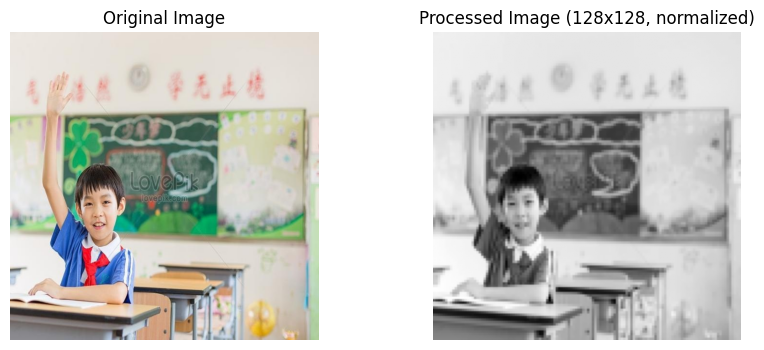

In [28]:
import numpy as np

def show_pipeline_example(image_path):
    original = load_image(image_path)
    processed = preprocess_image(image_path)

    plt.figure(figsize=(10,4))

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original[..., ::-1])
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Processed Image (128x128, normalized)")
    plt.imshow(processed, cmap="gray")
    plt.axis("off")

    print(f"Image: {image_path.name}")
    print(f"Processed shape: {processed.shape}")
    print(f"Min value: {processed.min():.4f}")
    print(f"Max value: {processed.max():.4f}")

show_pipeline_example(sample_images[0])


## Stage 2: Convolution Kernel Layer

### Demonstrates the effect of individual convolution kernels on the preprocessed image.

The pipeline includes:

1. Taking the preprocessed image (128x128, normalized)
2. Applying selected convolution kernels
3. Visualizing the resulting feature maps

Kernel used: sobel_vertical
Feature map shape: (128, 128)
Min value: -14.8446
Max value: 12.8141


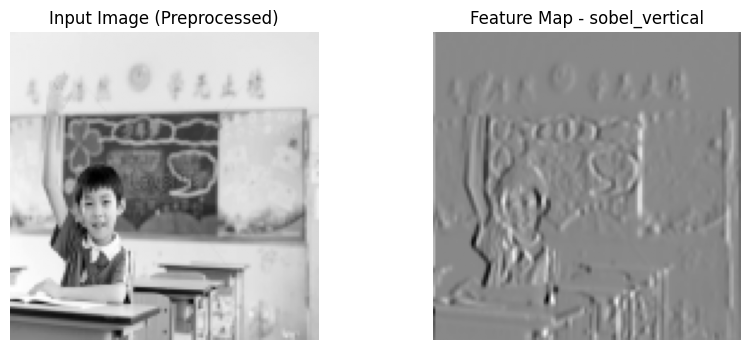

In [29]:
from model_free.conv_layer import apply_convolution, list_kernel_names, get_kernel

def show_single_kernel_effect(image_path, kernel_name):
    processed = preprocess_image(image_path)
    kernel = get_kernel(kernel_name)
    feature_map = apply_convolution(processed, kernel)

    plt.figure(figsize=(10,4))

    plt.subplot(1, 2, 1)
    plt.title("Input Image (Preprocessed)")
    plt.imshow(processed, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Feature Map - {kernel_name}")
    plt.imshow(feature_map, cmap="gray")
    plt.axis("off")

    print(f"Kernel used: {kernel_name}")
    print(f"Feature map shape: {feature_map.shape}")
    print(f"Min value: {feature_map.min():.4f}")
    print(f"Max value: {feature_map.max():.4f}")


# Example demonstration
show_single_kernel_effect(sample_images[0], "sobel_vertical")


## Stage 3: Multiple Kernels Pipeline Demonstration

### Demonstrates the full convolution pipeline:

1. optional smoothing
2. multiple kernels
3. ReLU
4. max pooling

And shows all resulting feature maps together.

Applied kernels: ['sobel_vertical', 'sobel_horizontal', 'laplacian', 'diagonal_main', 'diagonal_anti']
Stacked output shape: (5, 128, 128)
Format: (n_kernels, H, W)


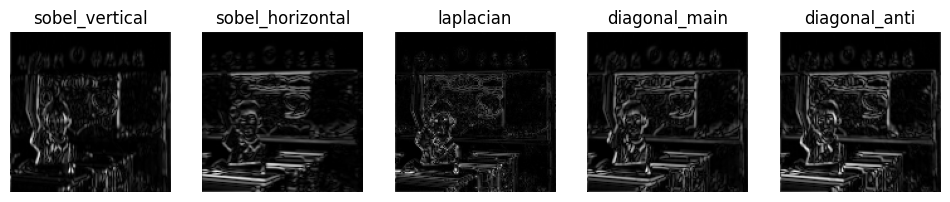

In [30]:
from model_free.conv_layer import process_image_with_kernels, DEFAULT_IMPORTANT_KERNELS

def show_multiple_kernels_effect(image_path):
    processed = preprocess_image(image_path)
    stacked_maps = process_image_with_kernels(processed)

    n_kernels = stacked_maps.shape[0]

    plt.figure(figsize=(12, 4))
    for i in range(n_kernels):
        plt.subplot(1, n_kernels, i + 1)
        plt.title(DEFAULT_IMPORTANT_KERNELS[i])
        plt.imshow(stacked_maps[i], cmap="gray")
        plt.axis("off")

    print("Applied kernels:", DEFAULT_IMPORTANT_KERNELS)
    print(f"Stacked output shape: {stacked_maps.shape}")
    print("Format: (n_kernels, H, W)")


# Example demonstration
show_multiple_kernels_effect(sample_images[0])

## Stage 4: Feature Extraction Demonstration

### Demonstrates computing feature vectors from stacked feature maps

The feature vector includes compact global statistics per image, such as:
 - sum_total_global
 - ratio_top_bottom
 - center_of_mass_y
 - avg_percent_above_threshold
 - horizontal_vs_vertical_ratio
 - max_overall
 - mean_of_means
 - std_of_means

In [31]:
from model_free.features import compute_feature_vector
from model_free.conv_layer import process_image_with_kernels, DEFAULT_IMPORTANT_KERNELS
from model_free.preprocessing import preprocess_image

def show_feature_vector_example(image_path):
    # preprocess image
    processed = preprocess_image(image_path)

    # apply convolution pipeline
    stacked_maps = process_image_with_kernels(processed)

    # compute compact feature vector
    vec, feature_names = compute_feature_vector(stacked_maps, kernel_names=DEFAULT_IMPORTANT_KERNELS)

    # display results
    print(f"Image: {image_path.name}")
    print("Feature vector:")
    for name, val in zip(feature_names, vec):
        print(f" - {name}: {val:.4f}")
    print(f"Vector shape: {vec.shape}")
    print(f"Stacked feature maps shape: {stacked_maps.shape}")

# Example demonstration
show_feature_vector_example(sample_images[0])

Image: img_001.jpg
Feature vector:
 - sum_total_global: 6526.0386
 - ratio_top_bottom: 0.5432
 - center_of_mass_y: 0.6059
 - avg_percent_above_threshold: 0.2607
 - horizontal_vs_vertical_ratio: 0.7881
 - max_overall: 1.0000
 - mean_of_means: 0.0797
 - std_of_means: 0.0148
 - mean_signed_vertical: 0.0636
 - mean_signed_horizontal: 0.0808
Vector shape: (10,)
Stacked feature maps shape: (5, 128, 128)


## Stage 5: Classification Demonstration

### Demonstrates the classification stage:

The pipeline includes:
1. Running the convolution + feature extraction pipeline
2. Predicting the label using the RULE-BASED classifier
3. Showing prediction, confidence score, and feature vector shape
4. Demonstrating batch classification

In [32]:
from model_free.classifier import classify_pose_rule, score_with_rule, predict_batch
from model_free.preprocessing import preprocess_image
from model_free.conv_layer import process_image_with_kernels, DEFAULT_IMPORTANT_KERNELS
from model_free.features import compute_feature_vector

def show_classification_example(image_path):
    processed = preprocess_image(image_path)
    stacked_maps = process_image_with_kernels(processed)
    vec, feature_names = compute_feature_vector(stacked_maps, kernel_names=DEFAULT_IMPORTANT_KERNELS)

    # compute score + label
    score = score_with_rule(vec, feature_names)
    label = classify_pose_rule(vec, feature_names)

    print(f"Image: {image_path.name}")
    print(f"Predicted label: {label}")
    print(f"Confidence score: {score:.6f}")
    print(f"Feature vector size: {vec.shape[0]}")
    print(f"Used {len(feature_names)} features")

# Example: run on first sample
show_classification_example(sample_images[0])


### Batch demonstration (multiple images)
def show_batch_classification(image_paths):
    import numpy as np
    feature_vectors = []
    valid_files = []

    for p in image_paths:
        try:
            processed = preprocess_image(p)
            stacked_maps = process_image_with_kernels(processed)
            vec, feature_names = compute_feature_vector(stacked_maps, kernel_names=DEFAULT_IMPORTANT_KERNELS)
            feature_vectors.append(vec)
            valid_files.append(p.name)
        except Exception as e:
            print(f"[WARN] failed to process {p.name}: {e}")

    if len(feature_vectors) == 0:
        print("No valid feature vectors, aborting batch classification.")
        return

    X = np.stack(feature_vectors, axis=0)
    labels_pred, scores = predict_batch(X, feature_names)  # use feature_names from first image

    print("\nBatch Classification Results:")
    for fname, lab, sc in zip(valid_files, labels_pred, scores):
        print(f" - {fname}: {lab} (score={sc:.6f})")


# Example: classify first 3 images in batch
show_batch_classification(sample_images)


Image: img_001.jpg
Predicted label: raised
Confidence score: 0.364278
Feature vector size: 10
Used 10 features

Batch Classification Results:
 - img_001.jpg: raised (score=0.364278)
 - img_002.jpg: raised (score=0.196932)
 - img_003.jpg: raised (score=0.357939)
